# 04 Segmentation and Networks

This notebook delivers the Phase 3 advanced analysis for **Netflix Catalog Strategy Analysis**. In the project sequence, it should be run **after `03_business_analysis.ipynb`** so the full project remains refreshed in order.

When rerun, this notebook overwrites its Phase 3 tables in `outputs/tables/` and its Phase 3 figures in `outputs/figures/`. The goal is to extend the earlier findings in three ways:

- trace how the catalog evolved over time rather than treating it as static inventory
- segment titles into a small number of interpretable strategic groups
- examine recurring talent ecosystems where people relationships meaningfully support catalog interpretation

The analysis remains grounded in metadata. It does **not** infer title performance, audience demand, retention, or revenue impact.


In [1]:

import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data/processed/titles.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
pd.options.display.float_format = lambda value: f'{value:,.3f}'

from src.feature_engineering import (
    build_cast_view,
    build_country_view,
    build_director_view,
    build_genre_view,
    build_segmentation_dataset,
    build_title_features,
    load_phase1_tables,
)
from src.metrics import (
    build_cast_coappearance_network,
    calendar_month_profile,
    cluster_dimension_profile,
    cluster_summary,
    director_cast_collaboration_table,
    distribution_table,
    evaluate_kmeans_cluster_range,
    fit_kmeans_segmentation,
    geographic_diversification_over_time,
    matrix_from_mix,
    mix_over_time,
    repeated_people_summary,
    standardized_profile_matrix,
)
from src.utils import ensure_directory, save_dataframe
from src.visualization import (
    TYPE_COLORS,
    apply_report_style,
    plot_cast_ecosystem_network,
    plot_cluster_profile_heatmap,
    plot_cluster_sizes,
    plot_geographic_diversification_over_time,
    plot_time_mix_heatmap,
    plot_time_mix_lines,
    plot_titles_added_profile,
    save_figure,
)

TABLES_DIR = ensure_directory(PROJECT_ROOT / 'outputs/tables')
FIGURES_DIR = ensure_directory(PROJECT_ROOT / 'outputs/figures')

def show_figure(file_name: str, width: int = 1080) -> None:
    display(Image(filename=str(FIGURES_DIR / file_name), width=width))


## Analytical Notes

- `date_added_year = 2020` is still a snapshot-year artifact rather than a full comparable year, so time-trend interpretation should focus more on direction than on 2020 absolute volume.
- The clustering design intentionally uses a small set of interpretable inputs: content type, rating group, recency, release-to-add lag, country breadth, genre breadth, and top-genre flags.
- The people-network section focuses on recurring catalog ecosystems, not social influence or causal creative value.
- Network outputs are kept deliberately narrow: one main graph and a few supporting tables are more portfolio-useful than a large number of technical network statistics.
- Rerunning this notebook replaces existing Phase 3 outputs in `outputs/tables/` and `outputs/figures/`.


In [2]:
apply_report_style()

tables = load_phase1_tables(PROJECT_ROOT / 'data/processed')
title_features = build_title_features(tables['titles'], tables['title_country'], tables['title_genre'])
country_view = build_country_view(title_features, tables['title_country'])
genre_view = build_genre_view(title_features, tables['title_genre'])
cast_view = build_cast_view(title_features, tables['title_cast'])
director_view = build_director_view(title_features, tables['title_director'])

print(f'Loaded processed tables from: {PROJECT_ROOT / 'data/processed'}')
display(title_features[['show_id', 'title', 'type', 'rating_group', 'release_year', 'date_added_year', 'release_to_add_lag_clean', 'country_count', 'genre_count']].head())


Loaded processed tables from: /Users/xinyue/Documents/projects/netflix_da/data/processed


,show_id,title,type,rating_group,release_year,date_added_year,release_to_add_lag_clean,country_count,genre_count
0,s1,Dick Johnson Is Dead,Movie,Teen,2020,2021,1,1,1
1,s10,The Starling,Movie,Teen,2021,2021,0,1,2
2,s100,On the Verge,TV Show,Mature,2021,2021,0,2,2
3,s1000,Stowaway,Movie,Mature,2021,2021,0,2,3
4,s1001,Wild Dog,Movie,Mature,2020,2021,1,0,2


## 1. Time Evolution of the Catalog

In [3]:

titles_added_by_year = distribution_table(title_features, 'date_added_year')
titles_added_by_month = calendar_month_profile(title_features)
type_mix_over_time = mix_over_time(title_features, 'type')
rating_mix_over_time = mix_over_time(title_features, 'rating_group')
genre_mix_over_time = mix_over_time(genre_view, 'genre', top_n_categories=8)
geographic_diversification = geographic_diversification_over_time(country_view)

rating_order = ['Kids', 'Family', 'Teen', 'Mature', 'Unknown / Unrated']
rating_mix_matrix = matrix_from_mix(
    rating_mix_over_time,
    'rating_group',
    'date_added_year',
    value_column='share_within_year',
).reindex(rating_order)

top_genre_order = (
    genre_mix_over_time.groupby('genre')['title_count']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)
genre_mix_matrix = matrix_from_mix(
    genre_mix_over_time,
    'genre',
    'date_added_year',
    value_column='share_within_year',
).reindex(top_genre_order)

for file_name, frame in {
    'phase3_titles_added_by_year.csv': titles_added_by_year,
    'phase3_titles_added_by_month.csv': titles_added_by_month,
    'phase3_type_mix_over_time.csv': type_mix_over_time,
    'phase3_rating_mix_over_time.csv': rating_mix_over_time,
    'phase3_genre_mix_over_time.csv': genre_mix_over_time,
    'phase3_geographic_diversification_over_time.csv': geographic_diversification,
}.items():
    save_dataframe(frame, TABLES_DIR / file_name)


In [4]:

figures = {
    'phase3_01_titles_added_profile.png': plot_titles_added_profile(titles_added_by_year, titles_added_by_month),
    'phase3_02_type_mix_over_time.png': plot_time_mix_lines(
        type_mix_over_time,
        category_column='type',
        value_column='share_within_year',
        title='Type mix of titles added over time',
        color_map=TYPE_COLORS,
    ),
    'phase3_03_rating_mix_over_time.png': plot_time_mix_heatmap(
        rating_mix_matrix,
        title='Rating mix of titles added over time',
    ),
    'phase3_04_genre_mix_over_time.png': plot_time_mix_heatmap(
        genre_mix_matrix,
        title='Top genre mix of titles added over time',
    ),
    'phase3_05_geographic_diversification_over_time.png': plot_geographic_diversification_over_time(
        geographic_diversification,
    ),
}

for file_name, figure in figures.items():
    save_figure(figure, FIGURES_DIR / file_name)
    plt.close(figure)


,date_added_year,title_count
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


,date_added_month,title_count,month_name,share
0,1,738,Jan,0.084
1,2,563,Feb,0.064
2,3,742,Mar,0.084
3,4,764,Apr,0.087
4,5,632,May,0.072
5,6,728,Jun,0.083
6,7,827,Jul,0.094
7,8,755,Aug,0.086
8,9,770,Sep,0.088
9,10,760,Oct,0.086


,date_added_year,type,title_count,year_total,share_within_year
12,2016,Movie,253,429,0.590
13,2016,TV Show,176,429,0.410
14,2017,Movie,839,1188,0.706
15,2017,TV Show,349,1188,0.294
16,2018,Movie,1237,1649,0.750
17,2018,TV Show,412,1649,0.250
18,2019,Movie,1424,2016,0.706
19,2019,TV Show,592,2016,0.294
20,2020,Movie,1284,1879,0.683
21,2020,TV Show,595,1879,0.317


,date_added_year,title_count,country_tag_count,distinct_countries,avg_countries_per_title,country_hhi,top_3_country_share
0,2008,2,2,1,1.000,1.000,1.000
1,2009,2,2,2,1.000,0.500,1.000
2,2010,1,1,1,1.000,1.000,1.000
3,2011,13,17,5,1.308,0.522,0.882
4,2012,3,4,2,1.333,0.625,1.000
5,2013,11,13,4,1.182,0.609,0.923
6,2014,24,34,9,1.417,0.439,0.824
7,2015,79,103,16,1.304,0.329,0.718
8,2016,410,539,52,1.315,0.167,0.532
9,2017,1123,1409,77,1.255,0.140,0.538


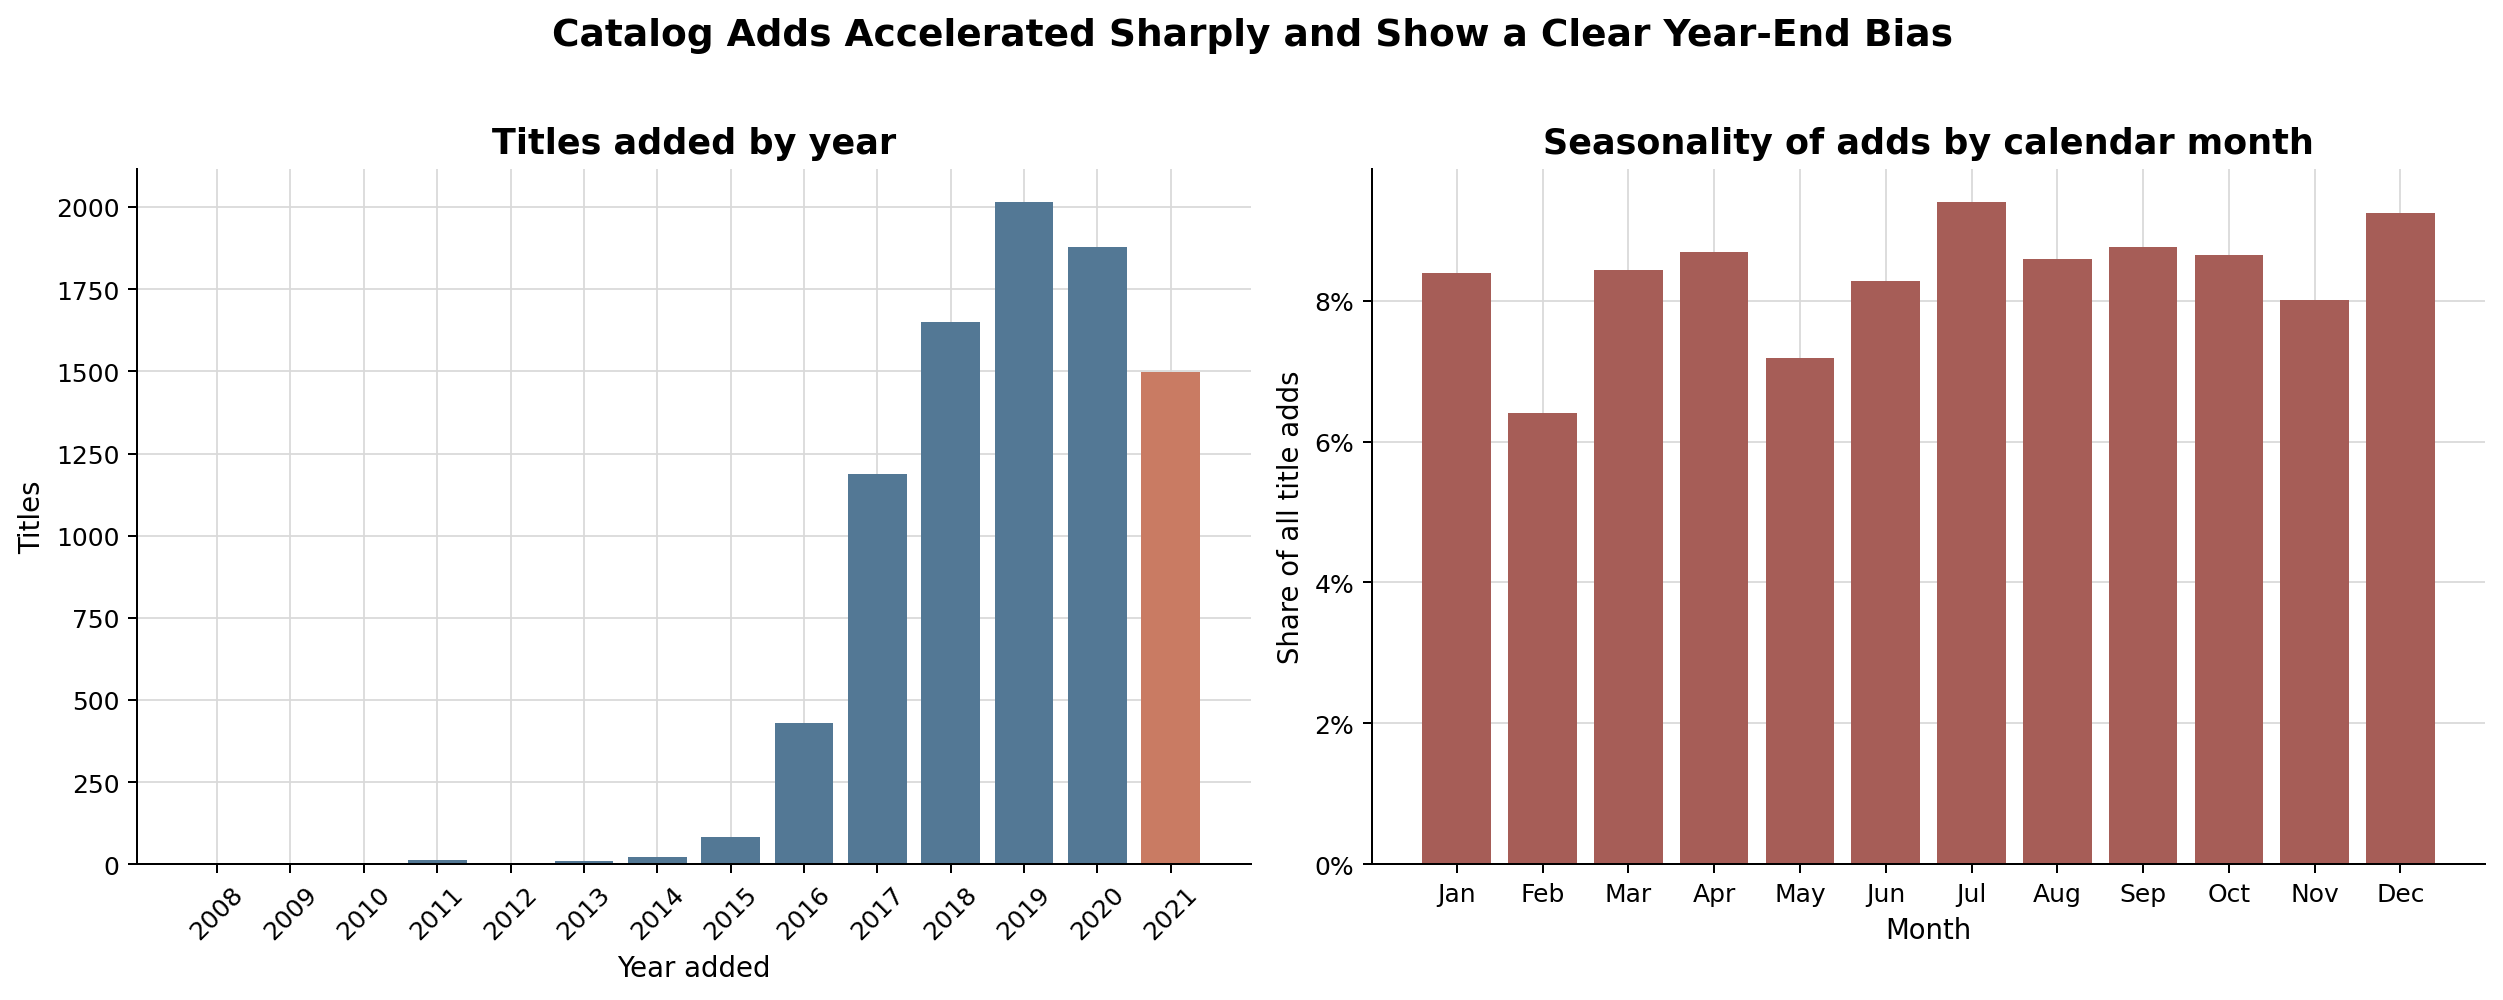

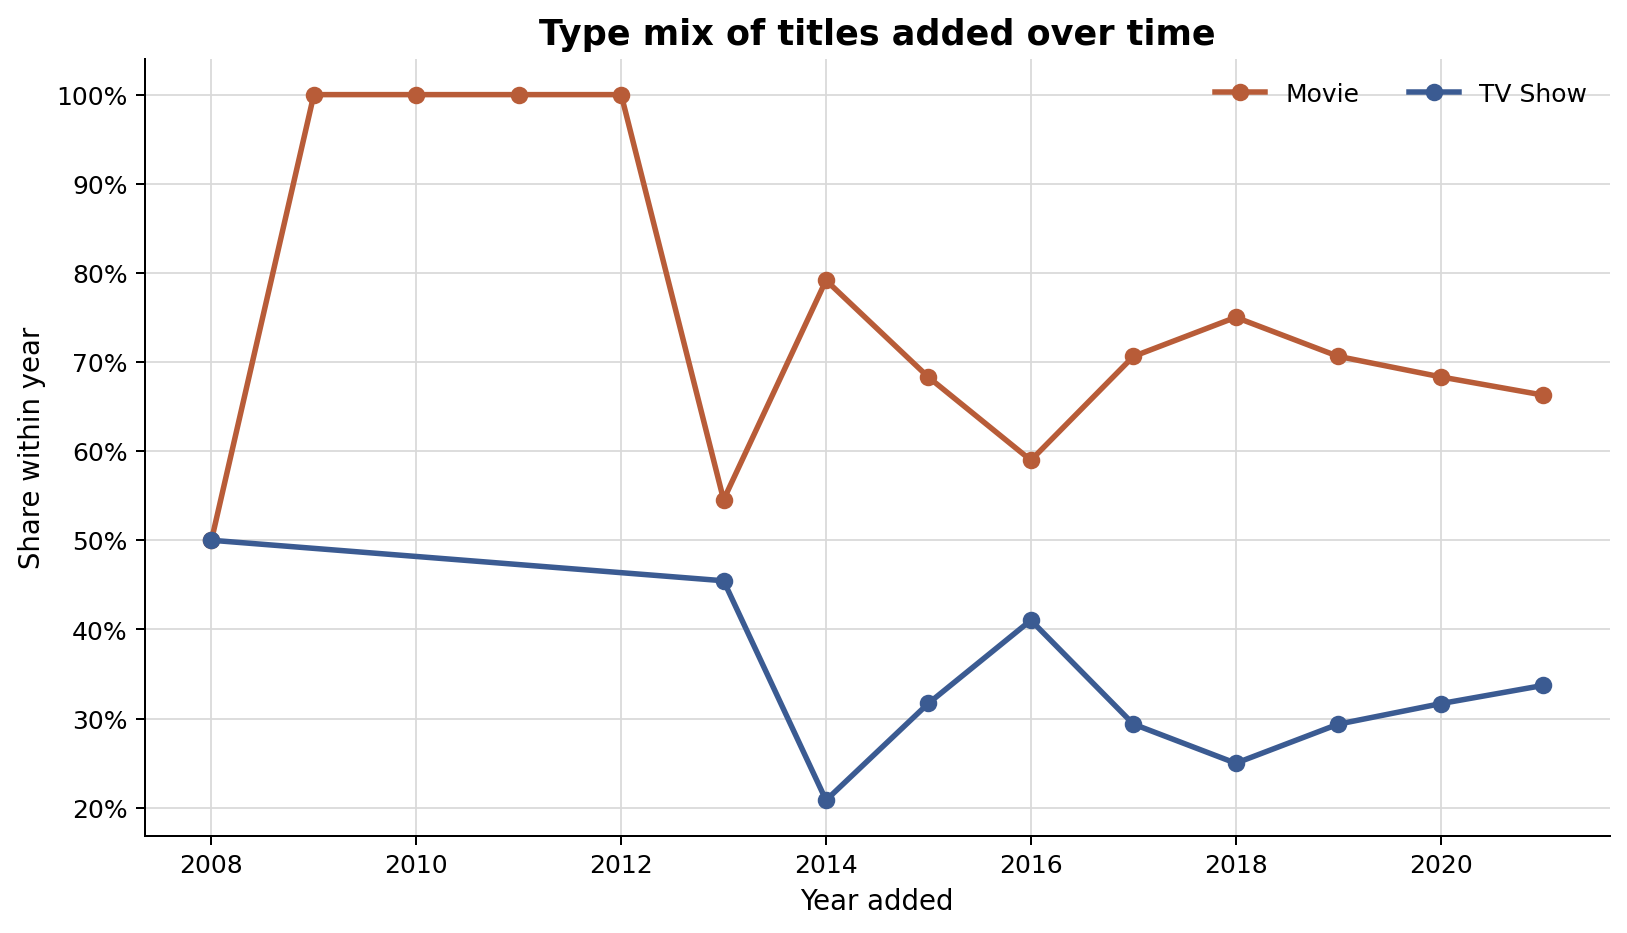

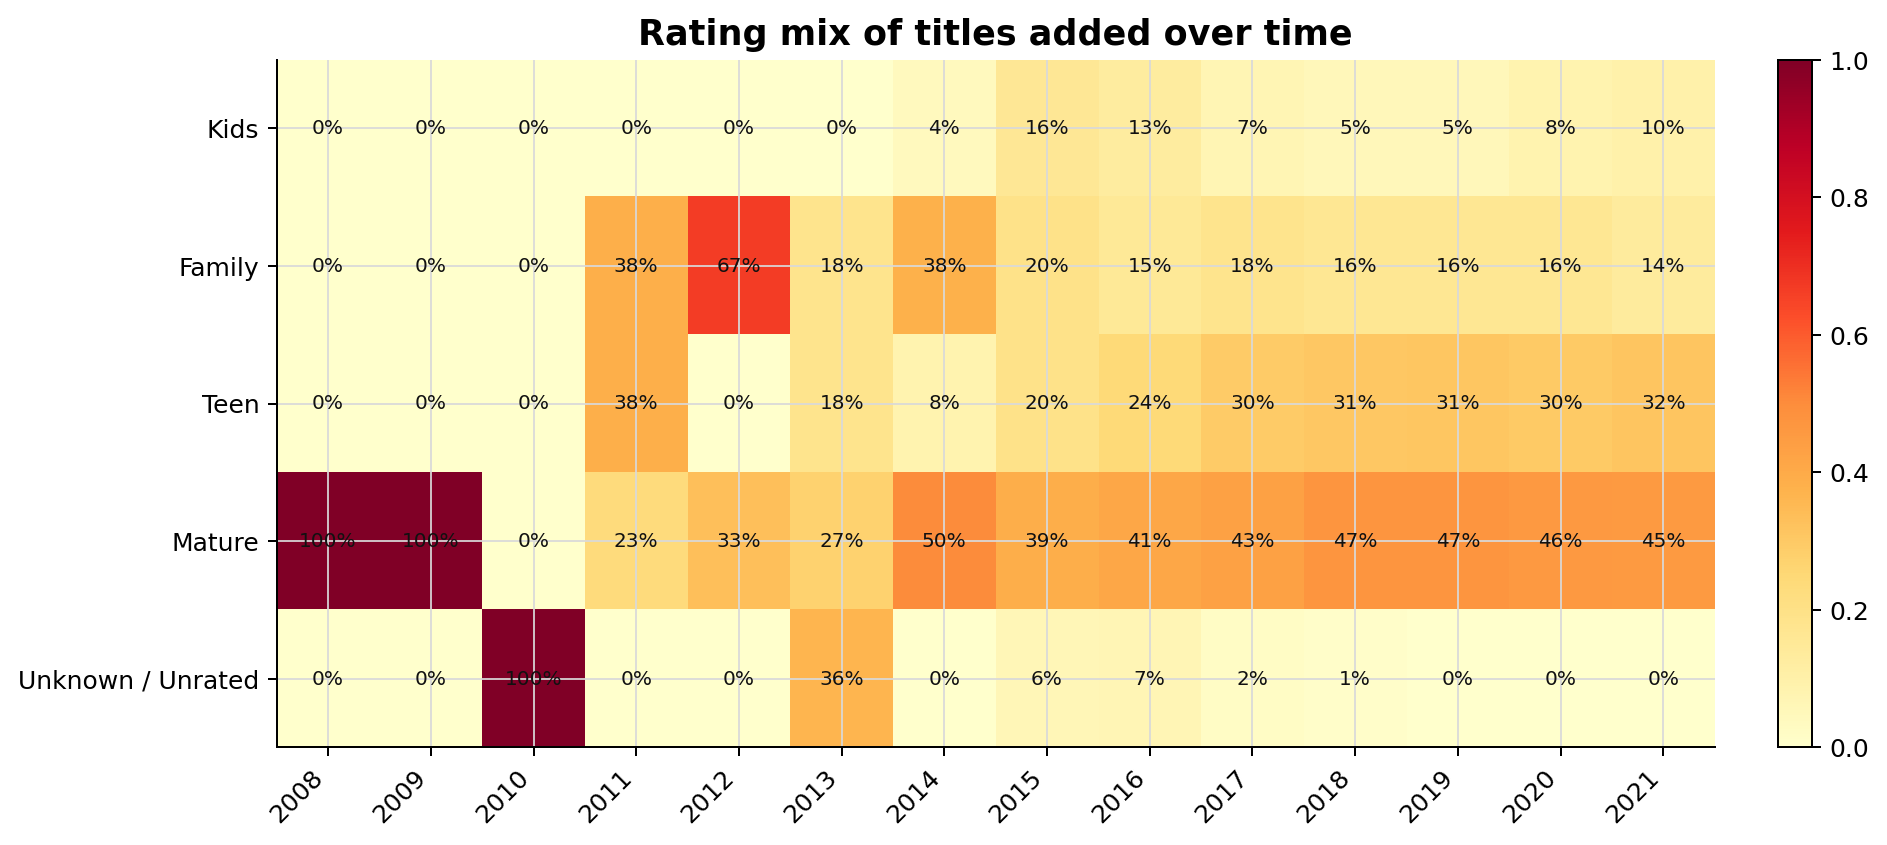

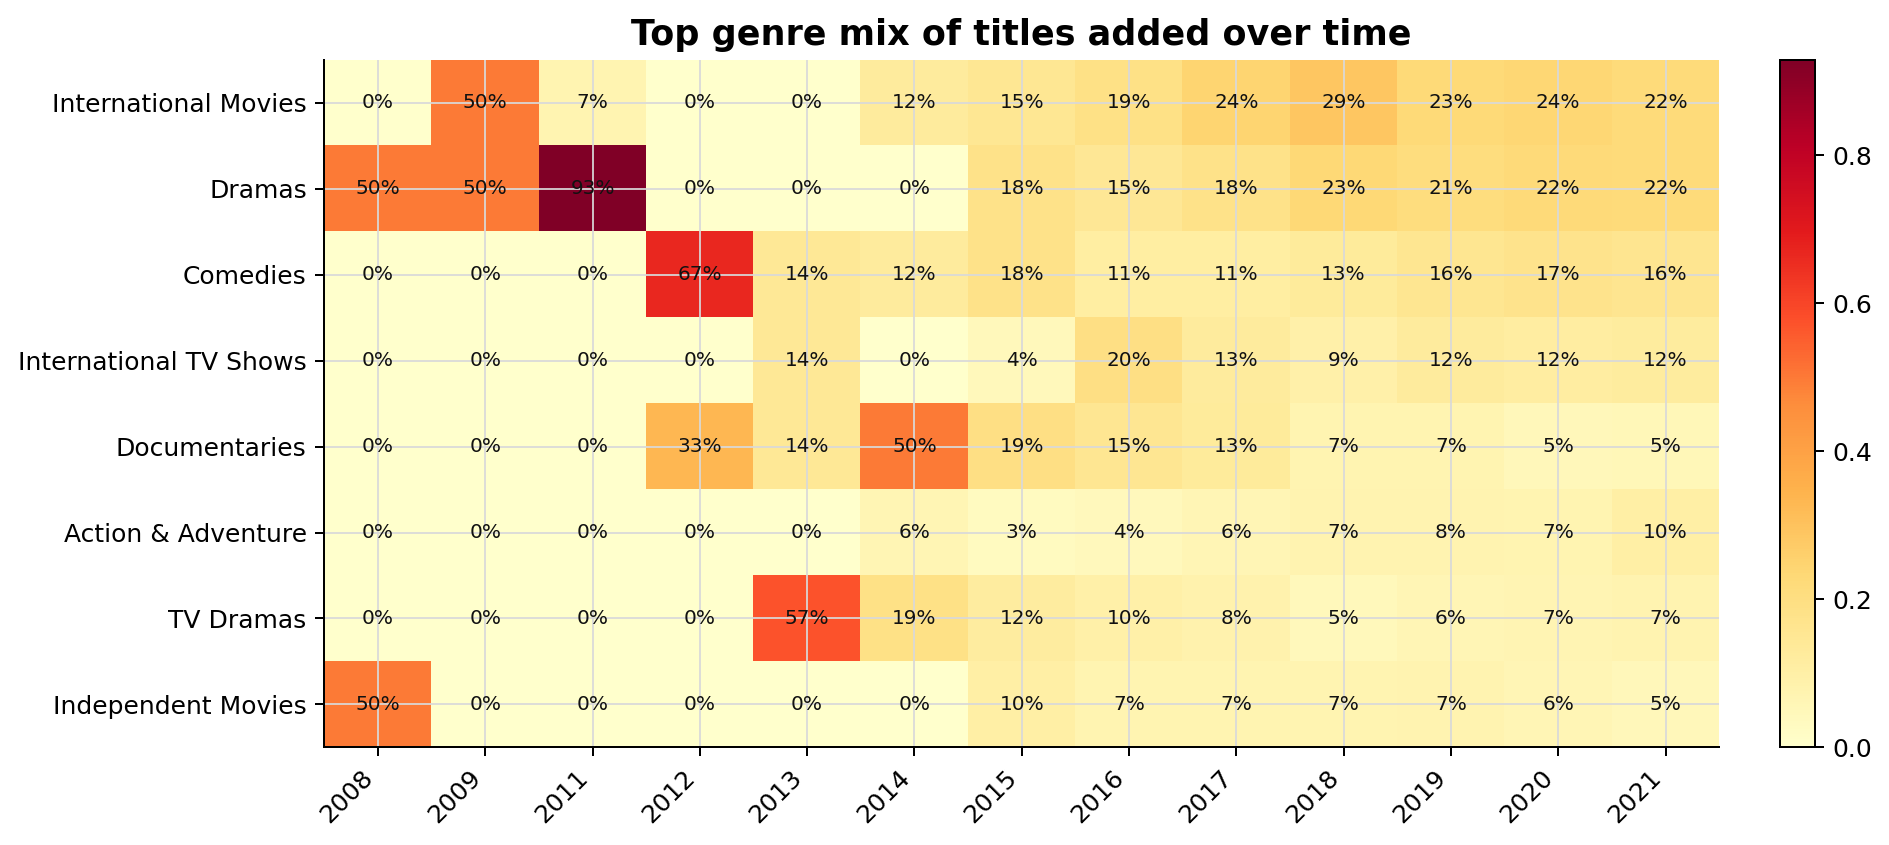

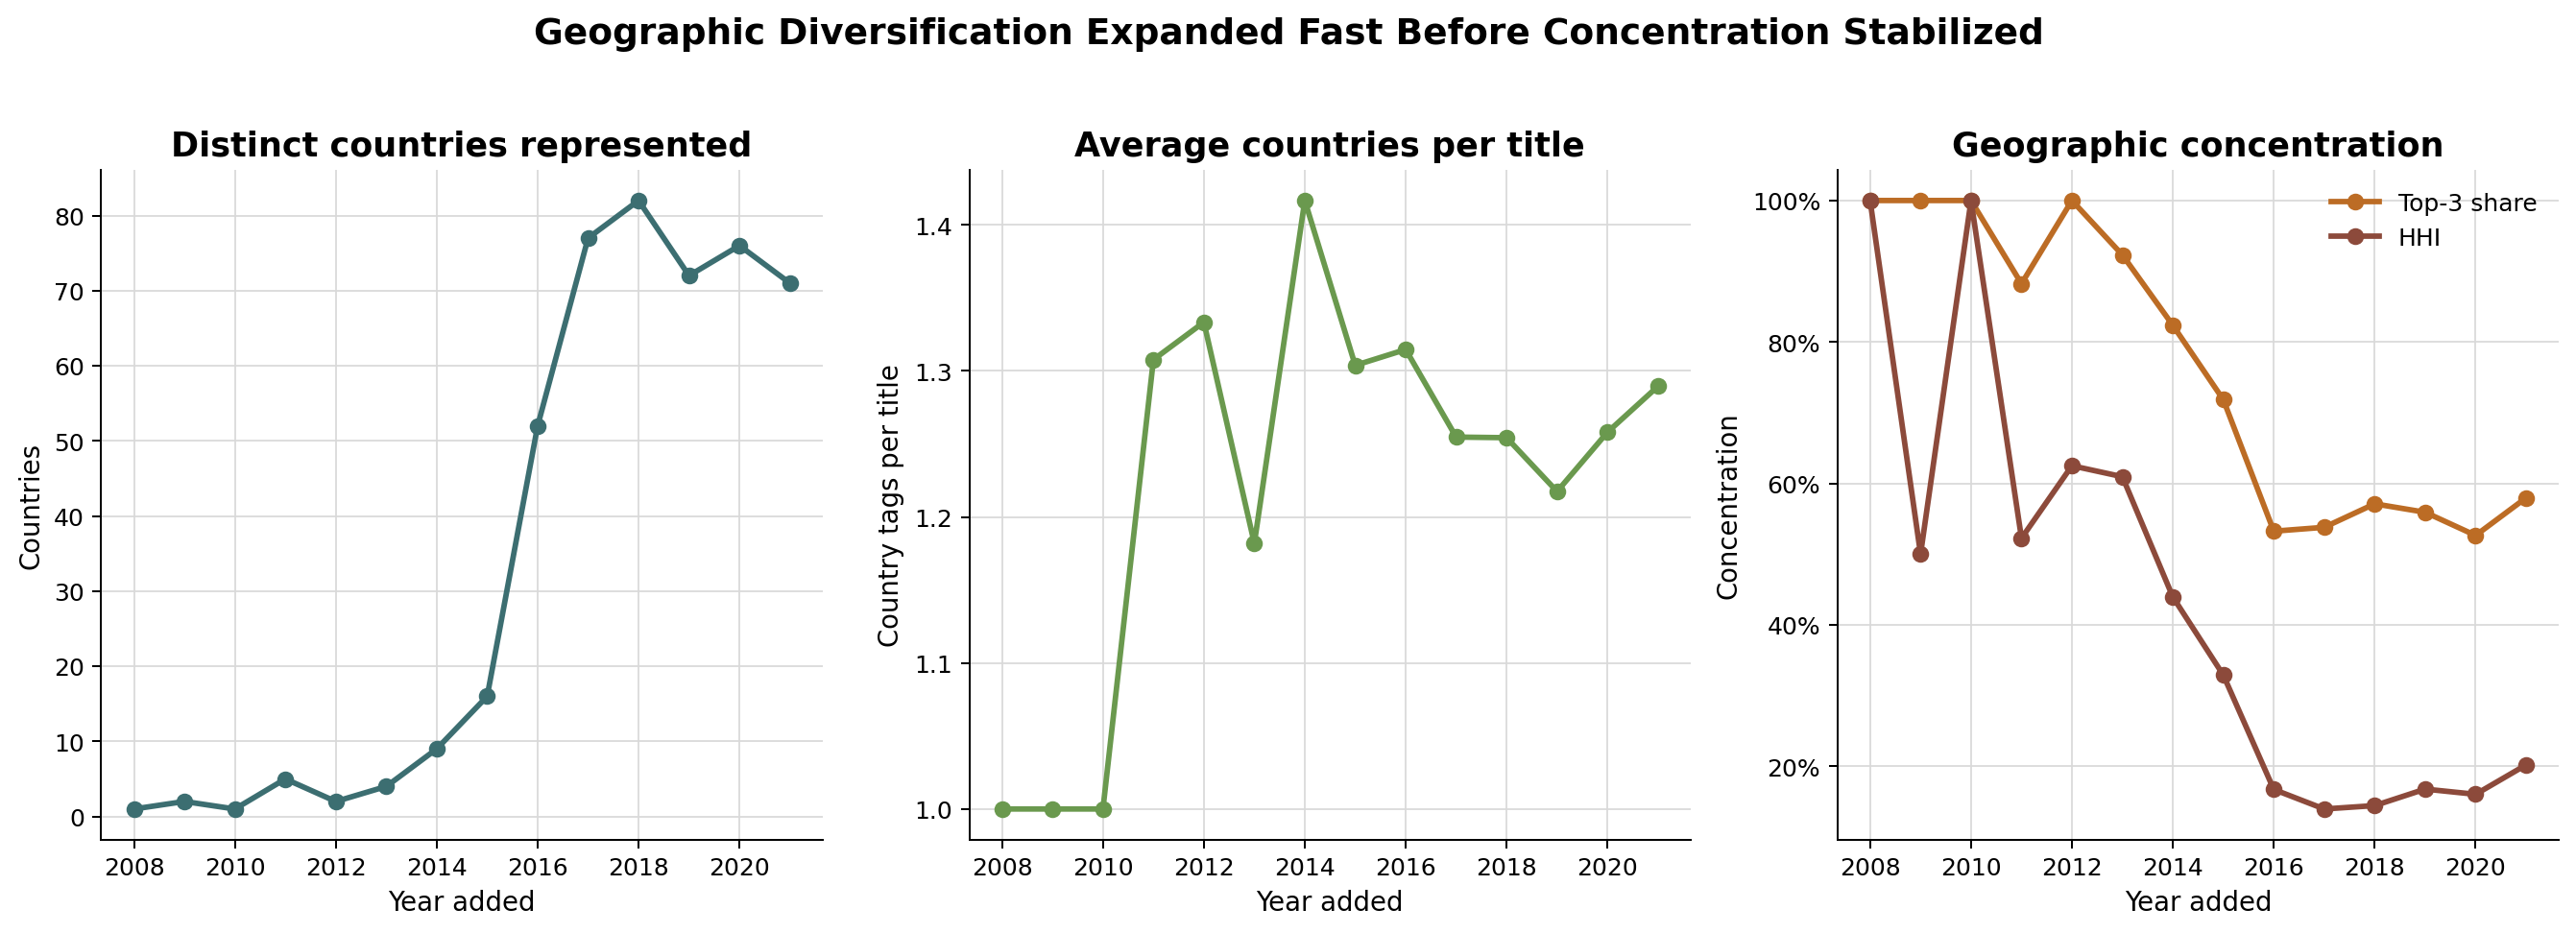

In [5]:

display(titles_added_by_year)
display(titles_added_by_month)
display(type_mix_over_time.tail(12))
display(geographic_diversification)
show_figure('phase3_01_titles_added_profile.png', width=1120)
show_figure('phase3_02_type_mix_over_time.png', width=1020)
show_figure('phase3_03_rating_mix_over_time.png', width=980)
show_figure('phase3_04_genre_mix_over_time.png', width=1020)
show_figure('phase3_05_geographic_diversification_over_time.png', width=1180)



**Observation**

- Title additions accelerated dramatically from the mid-2010s onward rather than growing at a steady linear pace.
- The month profile is not flat: the catalog shows a visible skew toward October through December adds.

**Interpretation**

- The catalog looks like it was scaled through a later-stage supply expansion, which matters because downstream mix changes are happening on top of a rapidly growing base.
- The year-end skew suggests a deliberate release-loading pattern rather than a purely uniform ingestion process.

**Business relevance**

- Strategy stakeholders care whether mix changes come from true repositioning or simply from volume ramp. This view clarifies that both things happened at once.
- Calendar concentration can inform how a catalog team thinks about seasonal packaging, launch waves, and reporting windows.



**Observation**

- Movies dominated the early add stream, but the TV Show share expanded materially once catalog growth accelerated.
- Even so, the library did not become TV-led; it became more balanced while remaining movie-heavy.

**Interpretation**

- Netflix appears to have used TV as a later strategic layer for differentiation, while Movies remained the scale engine of the catalog.
- The shift is consistent with a catalog strategy that broadened from library depth into recurring-series utility.

**Business relevance**

- This is a useful portfolio story for content strategy because it separates the platform's scale layer from its habit-forming series layer without claiming anything about performance.
- In a portfolio presentation, this chart shows that mix is dynamic and strategically managed rather than static inventory composition.



**Observation**

- The rating mix changed over time rather than staying fixed across years of catalog expansion.
- Mature and Teen inventory remained central, but Kids and Family shares also became more visible as the catalog broadened.

**Interpretation**

- Audience positioning expanded over time instead of moving toward a single maturity profile.
- That pattern suggests portfolio balancing: keeping an adult-oriented core while widening catalog utility for broader household use cases.

**Business relevance**

- This matters because audience positioning is one of the clearest strategic signals available in metadata when direct demand data is absent.
- A business-facing analysis should show how platform identity evolves at the portfolio level, and the rating heatmap does that cleanly.



**Observation**

- The genre mix did not simply get larger; it tilted more visibly toward internationally scalable drama, TV, and documentary buckets as additions ramped.
- A few genre families became recurring structural pillars across the growth years.

**Interpretation**

- The catalog evolved toward reusable, globally legible content buckets rather than an endlessly fragmented long tail.
- This supports the idea of a platform strategy anchored in a manageable set of high-coverage genre ecosystems.

**Business relevance**

- Genre strategy is easier to act on than title-level anecdotes. This view helps explain which content buckets increasingly define the library's identity.
- For a hiring manager, it demonstrates that the project goes beyond static shares into portfolio direction of travel.



**Observation**

- Geographic breadth expanded rapidly from a small early core into a much wider production footprint by the late 2010s.
- At the same time, concentration stopped falling after the main expansion wave, suggesting diversification gained momentum and then stabilized.

**Interpretation**

- Netflix's catalog appears to have moved from geographic scale-up into a more mature balancing phase: broader than before, but still anchored by a concentrated supply core.
- Diversification and concentration are both true at once, which is a more realistic portfolio story than either extreme alone.

**Business relevance**

- This is one of the strongest strategy outputs in the project because it links localization versus globalization framing to measurable structural change.
- It also gives a stakeholder-friendly way to discuss international breadth without pretending those country tags are demand shares.


## 2. Title Segmentation / Clustering


The clustering goal here is not novelty. It is to produce a small number of **business-readable title segments** that can summarize how different parts of the catalog behave on freshness, breadth, maturity positioning, and genre role.


In [6]:

segmentation_df, cluster_genre_lookup = build_segmentation_dataset(
    title_features,
    tables['title_genre'],
    top_n_genres=12,
)
cluster_numeric_columns = [
    'release_year',
    'release_to_add_lag_clean',
    'country_count',
    'genre_count',
    'is_recent_within_3y',
]
cluster_categorical_columns = ['type', 'rating_group']
cluster_binary_columns = cluster_genre_lookup['feature_column'].tolist()

cluster_model_selection = evaluate_kmeans_cluster_range(
    segmentation_df,
    numeric_columns=cluster_numeric_columns,
    categorical_columns=cluster_categorical_columns,
    binary_columns=cluster_binary_columns,
    cluster_values=range(4, 8),
)

clustered_titles, cluster_metadata = fit_kmeans_segmentation(
    segmentation_df,
    numeric_columns=cluster_numeric_columns,
    categorical_columns=cluster_categorical_columns,
    binary_columns=cluster_binary_columns,
    cluster_count=6,
)

cluster_label_map = {
    0: 'Recent International Movie Core',
    1: 'Legacy Mainstream Library',
    2: 'Recent International TV Series',
    3: 'Deep Library Classics',
    4: 'Multi-country Co-productions',
    5: 'Current Factual and Family Programming',
}
cluster_description_map = {
    0: 'Recent movie-heavy cluster with quick catalog entry and strong international genre coverage.',
    1: 'Older, longer-lag library titles anchored in mainstream movie genres with some spillover TV inventory.',
    2: 'Very recent TV-first cluster centered on international drama, crime, and serialized formats.',
    3: 'Small deep-library pocket dominated by classic and long-lag film inventory.',
    4: 'Cross-border co-production cluster with the broadest country footprint per title.',
    5: 'Recent factual, stand-up, and family-oriented programming cluster with strong US skew.',
}

clustered_titles['cluster_label'] = clustered_titles['cluster_id'].map(cluster_label_map)
cluster_label_dictionary = pd.DataFrame(
    [
        {
            'cluster_id': cluster_id,
            'cluster_label': cluster_label_map[cluster_id],
            'business_definition': cluster_description_map[cluster_id],
        }
        for cluster_id in sorted(cluster_label_map)
    ]
)

clustered_genre_view = genre_view.merge(
    clustered_titles[['show_id', 'cluster_id', 'cluster_label']],
    on='show_id',
    how='left',
)
clustered_country_view = country_view.merge(
    clustered_titles[['show_id', 'cluster_id', 'cluster_label']],
    on='show_id',
    how='left',
)

cluster_summary_table = cluster_summary(clustered_titles).merge(
    cluster_label_dictionary,
    on='cluster_id',
    how='left',
)
cluster_summary_table = cluster_summary_table[
    [
        'cluster_id',
        'cluster_label',
        'business_definition',
        'title_count',
        'cluster_share',
        'movie_share',
        'tv_share',
        'mature_share',
        'kids_share',
        'median_release_year',
        'median_lag',
        'multi_country_share',
        'recent_share',
        'median_country_count',
        'median_genre_count',
    ]
].sort_values('cluster_id').reset_index(drop=True)

cluster_genre_profile = cluster_dimension_profile(
    clustered_genre_view,
    dimension_column='genre',
    top_n=5,
).merge(cluster_label_dictionary[['cluster_id', 'cluster_label']], on='cluster_id', how='left')
cluster_country_profile = cluster_dimension_profile(
    clustered_country_view,
    dimension_column='country',
    top_n=5,
).merge(cluster_label_dictionary[['cluster_id', 'cluster_label']], on='cluster_id', how='left')

cluster_profile_matrix = standardized_profile_matrix(
    cluster_summary_table,
    index_column='cluster_label',
    value_columns=[
        'cluster_share',
        'movie_share',
        'mature_share',
        'median_release_year',
        'median_lag',
        'multi_country_share',
        'recent_share',
        'median_country_count',
        'median_genre_count',
    ],
).rename(
    columns={
        'cluster_share': 'Cluster size',
        'movie_share': 'Movie skew',
        'mature_share': 'Mature skew',
        'median_release_year': 'Release recency',
        'median_lag': 'Release-to-add lag',
        'multi_country_share': 'Multi-country share',
        'recent_share': 'Recent share',
        'median_country_count': 'Country breadth',
        'median_genre_count': 'Genre breadth',
    }
)

cluster_assignment_output = clustered_titles[
    [
        'show_id', 'title', 'type', 'rating_group', 'release_year', 'date_added_year',
        'release_to_add_lag_clean', 'country_count', 'genre_count', 'cluster_id', 'cluster_label'
    ]
].sort_values(['cluster_id', 'title']).reset_index(drop=True)

for file_name, frame in {
    'phase3_cluster_model_selection.csv': cluster_model_selection,
    'phase3_cluster_label_dictionary.csv': cluster_label_dictionary,
    'phase3_title_cluster_assignments.csv': cluster_assignment_output,
    'phase3_cluster_summary.csv': cluster_summary_table,
    'phase3_cluster_genre_profile.csv': cluster_genre_profile,
    'phase3_cluster_country_profile.csv': cluster_country_profile,
}.items():
    save_dataframe(frame, TABLES_DIR / file_name)

cluster_metadata


{'silhouette_score': 0.2151177028828397,
 'feature_matrix_shape': (8807, 25),
 'feature_names': ['numeric__release_year',
  'numeric__release_to_add_lag_clean',
  'numeric__country_count',
  'numeric__genre_count',
  'numeric__is_recent_within_3y',
  'categorical__type_Movie',
  'categorical__type_TV Show',
  'categorical__rating_group_Family',
  'categorical__rating_group_Kids',
  'categorical__rating_group_Mature',
  'categorical__rating_group_Other',
  'categorical__rating_group_Teen',
  'categorical__rating_group_Unknown / Unrated',
  'binary__genre_flag_international_movies',
  'binary__genre_flag_dramas',
  'binary__genre_flag_comedies',
  'binary__genre_flag_international_tv_shows',
  'binary__genre_flag_documentaries',
  'binary__genre_flag_action_adventure',
  'binary__genre_flag_tv_dramas',
  'binary__genre_flag_independent_movies',
  'binary__genre_flag_children_family_movies',
  'binary__genre_flag_romantic_movies',
  'binary__genre_flag_tv_comedies',
  'binary__genre_flag_

In [7]:

figures = {
    'phase3_06_cluster_size_summary.png': plot_cluster_sizes(cluster_summary_table),
    'phase3_07_cluster_profile_heatmap.png': plot_cluster_profile_heatmap(cluster_profile_matrix),
}

for file_name, figure in figures.items():
    save_figure(figure, FIGURES_DIR / file_name)
    plt.close(figure)


,cluster_count,silhouette_score,min_cluster_share,max_cluster_share,cluster_share_vector
0,4,0.198,0.047,0.398,0.287|0.398|0.047|0.268
1,5,0.213,0.047,0.380,0.247|0.380|0.277|0.049|0.047
2,6,0.215,0.047,0.278,0.047|0.185|0.194|0.247|0.049|0.278
3,7,0.211,0.042,0.299,0.299|0.163|0.146|0.042|0.048|0.194|0.107


,cluster_id,cluster_label,business_definition
0,0,Recent International Movie Core,Recent movie-heavy cluster with quick catalog ...
1,1,Legacy Mainstream Library,"Older, longer-lag library titles anchored in m..."
2,2,Recent International TV Series,Very recent TV-first cluster centered on inter...
3,3,Deep Library Classics,Small deep-library pocket dominated by classic...
4,4,Multi-country Co-productions,Cross-border co-production cluster with the br...
5,5,Current Factual and Family Programming,"Recent factual, stand-up, and family-oriented ..."


,cluster_id,cluster_label,business_definition,title_count,cluster_share,movie_share,tv_share,mature_share,kids_share,median_release_year,median_lag,multi_country_share,recent_share,median_country_count,median_genre_count
0,0,Recent International Movie Core,Recent movie-heavy cluster with quick catalog ...,412,0.047,0.930,0.070,0.311,0.010,"1,986.000",33.000,0.133,0.000,1.000,2.500
1,1,Legacy Mainstream Library,"Older, longer-lag library titles anchored in m...",1630,0.185,0.752,0.248,0.467,0.174,"2,018.000",0.000,0.067,0.997,1.000,1.000
2,2,Recent International TV Series,Very recent TV-first cluster centered on inter...,1710,0.194,0.000,1.000,0.523,0.075,"2,019.000",0.000,0.070,0.999,1.000,3.000
3,3,Deep Library Classics,Small deep-library pocket dominated by classic...,2171,0.247,0.788,0.212,0.340,0.068,"2,011.000",8.000,0.129,0.000,1.000,2.000
4,4,Multi-country Co-productions,Cross-border co-production cluster with the br...,435,0.049,0.837,0.163,0.485,0.087,"2,016.000",3.000,1.000,0.572,3.000,2.000
5,5,Current Factual and Family Programming,"Recent factual, stand-up, and family-oriented ...",2449,0.278,1.000,0.000,0.521,0.018,"2,018.000",1.000,0.129,1.000,1.000,3.000


,cluster_id,genre,title_count,cluster_total_titles,share_within_cluster,overall_title_share,lift_vs_overall,rank_within_cluster,cluster_label
0,0,Dramas,172,412,0.417,0.276,1.515,1,Recent International Movie Core
1,0,International Movies,131,412,0.318,0.312,1.018,2,Recent International Movie Core
2,0,Comedies,116,412,0.282,0.190,1.481,3,Recent International Movie Core
3,0,Classic Movies,114,412,0.277,0.013,21.008,4,Recent International Movie Core
4,0,Action & Adventure,113,412,0.274,0.098,2.812,5,Recent International Movie Core
5,1,Documentaries,454,1630,0.279,0.099,2.823,1,Legacy Mainstream Library
6,1,Stand-Up Comedy,277,1630,0.170,0.039,4.363,2,Legacy Mainstream Library
7,1,Children & Family Movies,182,1630,0.112,0.073,1.534,3,Legacy Mainstream Library
8,1,Kids' TV,147,1630,0.090,0.051,1.761,4,Legacy Mainstream Library
9,1,Comedies,79,1630,0.048,0.190,0.255,5,Legacy Mainstream Library


,cluster_id,country,title_count,cluster_total_titles,share_within_cluster,overall_title_share,lift_vs_overall,rank_within_cluster,cluster_label
0,0,United States,232,391,0.593,0.463,1.283,1,Recent International Movie Core
1,0,India,68,391,0.174,0.131,1.326,2,Recent International Movie Core
2,0,United Kingdom,35,391,0.090,0.101,0.886,3,Recent International Movie Core
3,0,Hong Kong,31,391,0.079,0.013,6.023,4,Recent International Movie Core
4,0,Egypt,14,391,0.036,0.015,2.441,5,Recent International Movie Core
5,1,United States,1090,1398,0.780,0.463,1.685,1,Legacy Mainstream Library
6,1,United Kingdom,115,1398,0.082,0.101,0.814,2,Legacy Mainstream Library
7,1,Canada,80,1398,0.057,0.056,1.026,3,Legacy Mainstream Library
8,1,Mexico,28,1398,0.020,0.021,0.945,4,Legacy Mainstream Library
9,1,India,22,1398,0.016,0.131,0.120,5,Legacy Mainstream Library


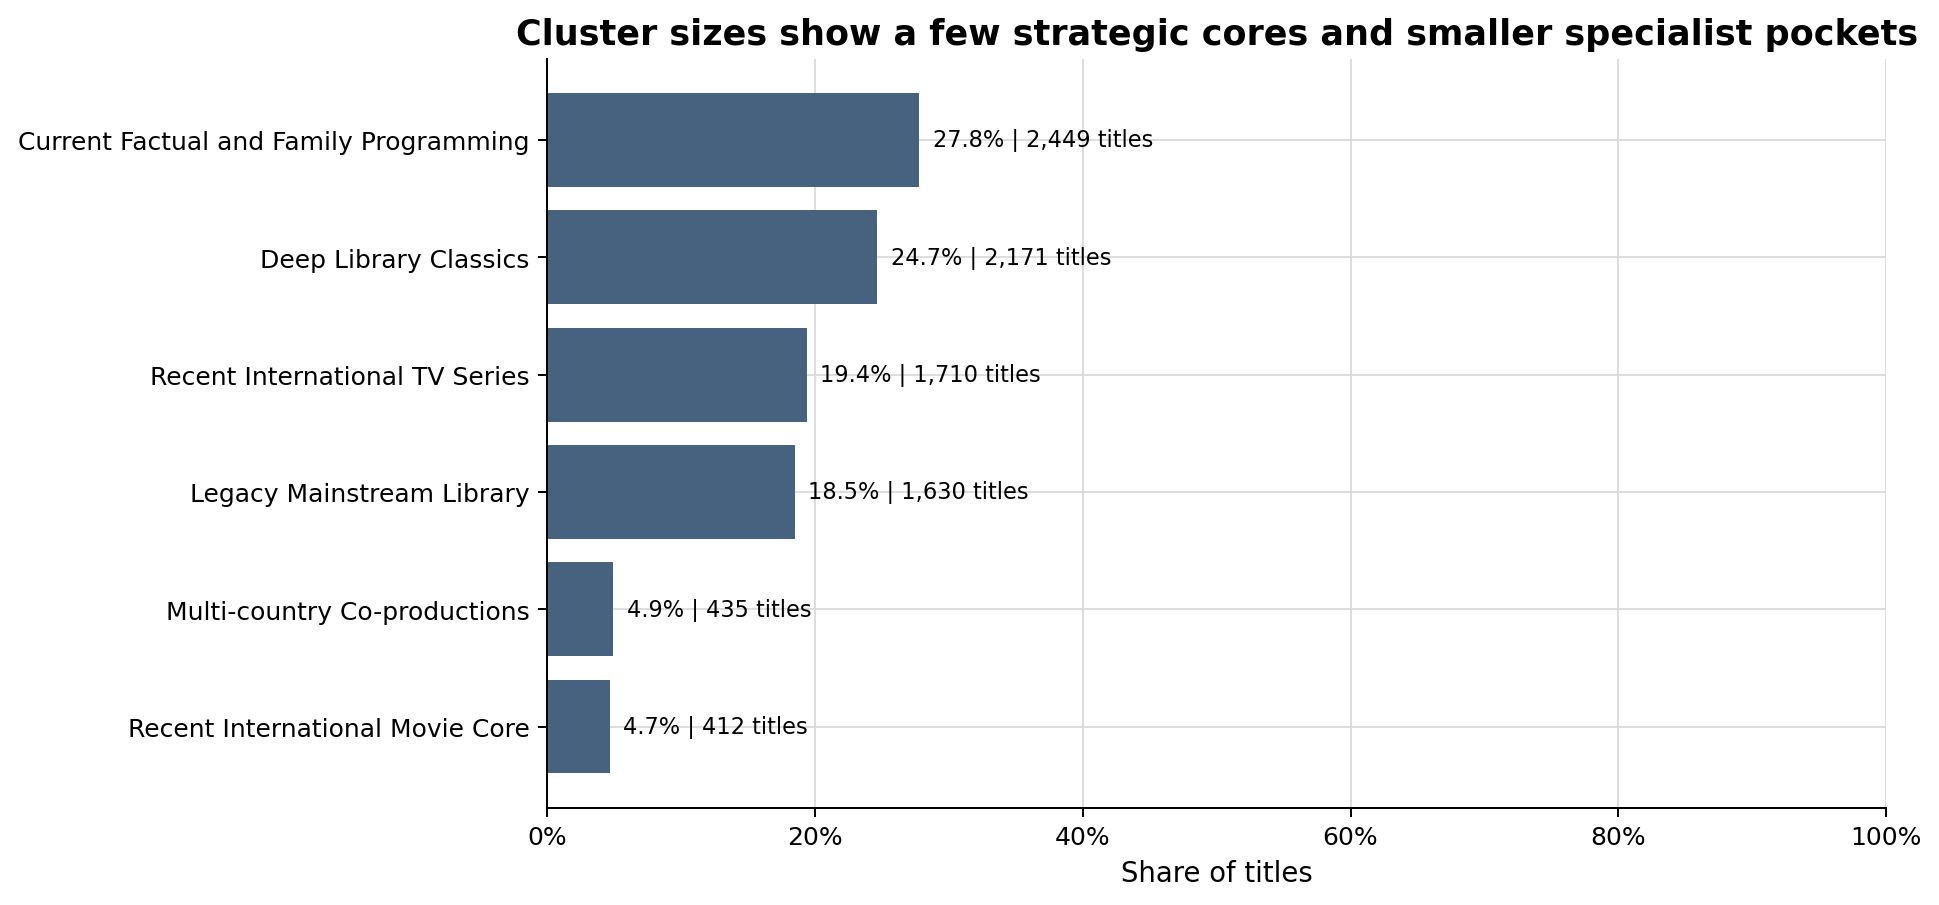

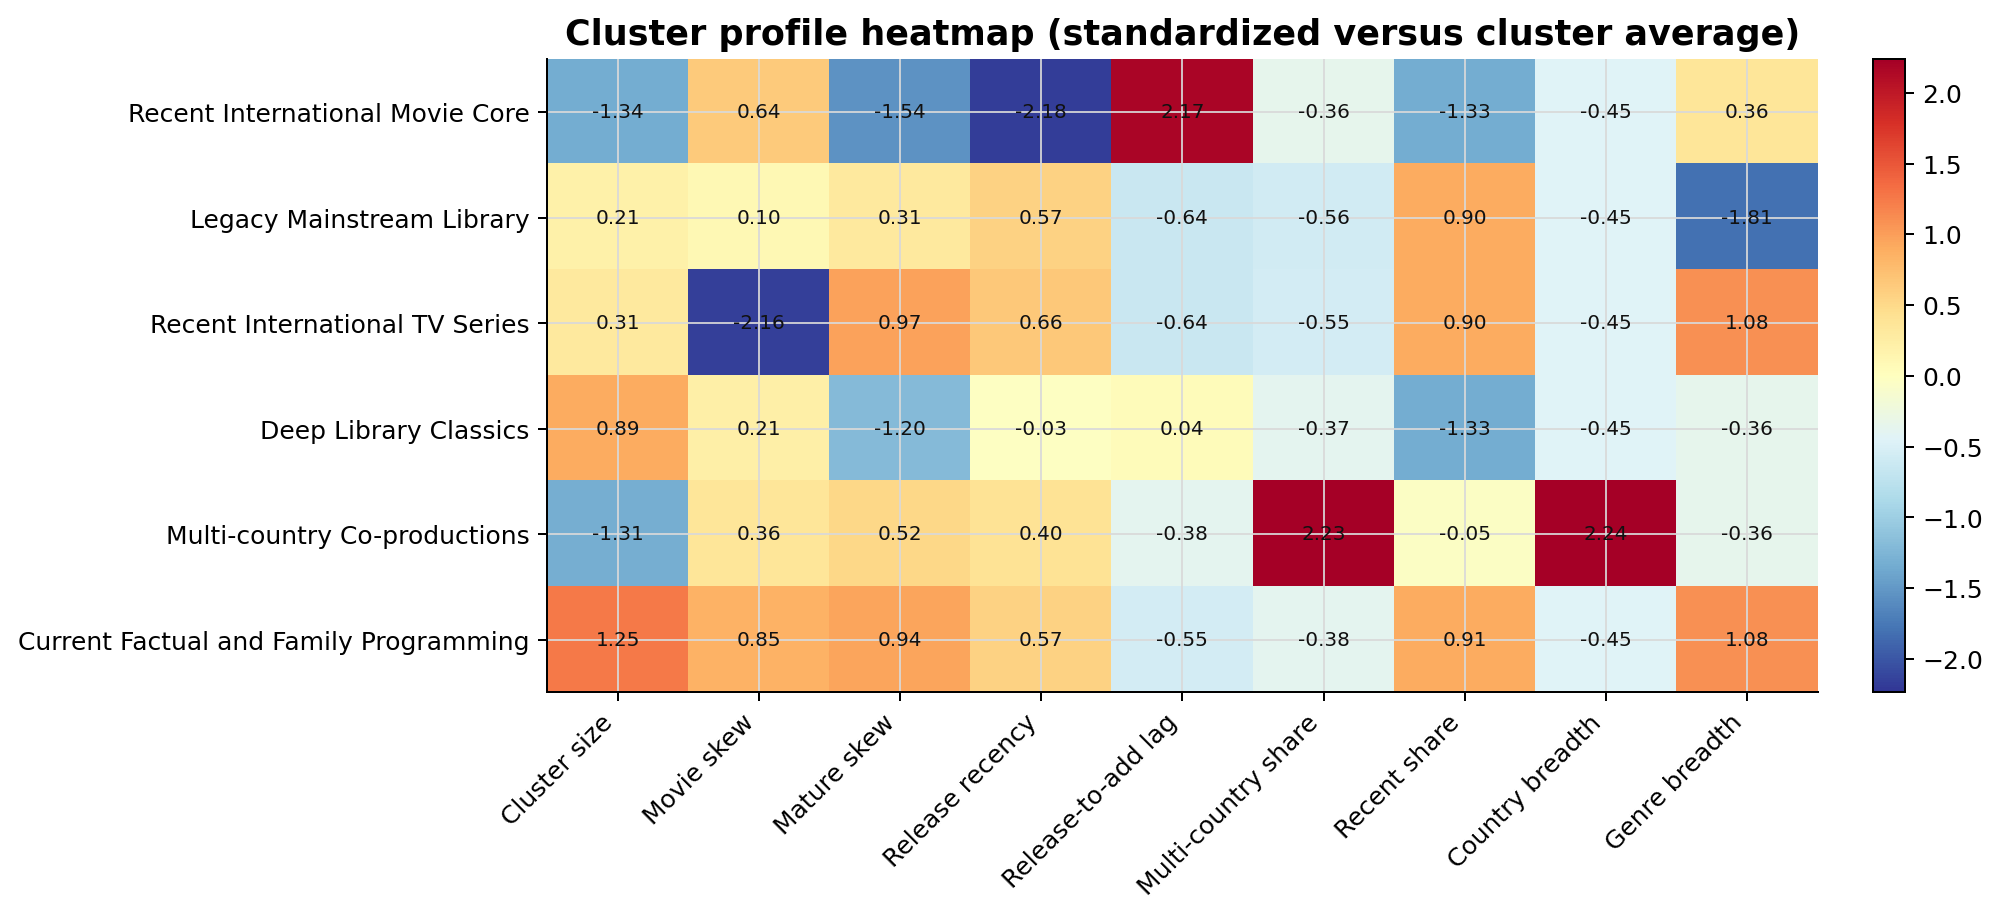

In [8]:

display(cluster_model_selection)
display(cluster_label_dictionary)
display(cluster_summary_table)
display(cluster_genre_profile)
display(cluster_country_profile)
show_figure('phase3_06_cluster_size_summary.png', width=1100)
show_figure('phase3_07_cluster_profile_heatmap.png', width=1180)



**Observation**

- The best compact solution still sits around `k = 6`, where clusters stay reasonably balanced while silhouette quality remains strongest in the tested range.
- The resulting segments are not trivial duplicates of `type`; they separate freshness, lag, country breadth, and content role into visibly different strategic groups.

**Interpretation**

- A useful portfolio segmentation can be built without opaque methods if the input features reflect business structure rather than raw text noise.
- The six-cluster solution effectively splits the catalog into scale cores, specialist pockets, and legacy inventory layers.

**Business relevance**

- This is the step that turns the project from descriptive analysis into strategic portfolio interpretation.
- For portfolio use, the cluster labels make it easier to discuss catalog strategy in stakeholder language rather than only in raw genre shares.



**Observation**

- Two large clusters anchor the library: a recent international movie core and a legacy mainstream library layer.
- TV forms its own recent international segment, while smaller but distinctive pockets capture deep-library classics, multi-country co-productions, and factual or family-oriented current programming.

**Interpretation**

- The catalog behaves less like one monolithic library and more like a set of supply strategies with different freshness and localization roles.
- The profile heatmap is especially useful because it shows where breadth, maturity, recency, and lag move together rather than one variable at a time.

**Business relevance**

- These segments are reusable communication assets for an executive summary: they give a business reader a fast mental model of the portfolio.
- They also create a bridge into Phase 4 because an executive summary can now describe the catalog in labeled strategic building blocks instead of dozens of disconnected charts.


## 3. People Network Analysis


The goal of the people analysis is to identify **recurring creative ecosystems** rather than produce abstract graph metrics. Tables capture repeat presence and recurring collaborations, while a single network view highlights which talent communities appear repeatedly inside the catalog metadata.


In [9]:

repeated_directors = repeated_people_summary(
    tables['title_director'],
    primary_column='director',
    counterpart_bridge=tables['title_cast'],
    counterpart_column='cast_member',
    top_n=20,
)
repeated_cast = repeated_people_summary(
    tables['title_cast'],
    primary_column='cast_member',
    counterpart_bridge=tables['title_director'],
    counterpart_column='director',
    top_n=20,
)
director_cast_collaborations = director_cast_collaboration_table(
    tables['title_director'],
    tables['title_cast'],
    min_titles=2,
    top_n=25,
)
cast_network_edges, cast_network_nodes, cast_community_summary = build_cast_coappearance_network(
    tables['title_cast'],
    top_n_cast=60,
    min_edge_weight=3,
)

community_label_map = {
    1: 'Indian film ensemble',
    2: 'Western animation voice cluster',
    3: 'Anime voice cluster',
    4: 'US animation and game voice cluster',
    5: 'Monty Python comedy cluster',
}
cast_community_summary['ecosystem_label'] = cast_community_summary['community_id'].map(community_label_map)
cast_community_summary['ecosystem_label'] = cast_community_summary['ecosystem_label'].fillna(
    cast_community_summary['community_id'].apply(lambda value: f'Other recurring ecosystem {value}')
)
cast_network_nodes = cast_network_nodes.merge(
    cast_community_summary[['community_id', 'ecosystem_label']],
    on='community_id',
    how='left',
)
cast_ecosystem_hubs = cast_network_nodes.sort_values('weighted_degree', ascending=False).reset_index(drop=True)

for file_name, frame in {
    'phase3_repeated_directors.csv': repeated_directors,
    'phase3_repeated_cast.csv': repeated_cast,
    'phase3_director_cast_collaborations.csv': director_cast_collaborations,
    'phase3_cast_network_edges.csv': cast_network_edges,
    'phase3_cast_network_nodes.csv': cast_network_nodes,
    'phase3_cast_community_summary.csv': cast_community_summary,
    'phase3_cast_ecosystem_hubs.csv': cast_ecosystem_hubs,
}.items():
    save_dataframe(frame, TABLES_DIR / file_name)


In [10]:

cast_network_figure = plot_cast_ecosystem_network(cast_network_nodes, cast_network_edges, label_top_n=14)
save_figure(cast_network_figure, FIGURES_DIR / 'phase3_08_cast_ecosystem_network.png')
plt.close(cast_network_figure)


In [11]:
phase3_table_files = [
    'phase3_titles_added_by_year.csv',
    'phase3_titles_added_by_month.csv',
    'phase3_type_mix_over_time.csv',
    'phase3_rating_mix_over_time.csv',
    'phase3_genre_mix_over_time.csv',
    'phase3_geographic_diversification_over_time.csv',
    'phase3_cluster_model_selection.csv',
    'phase3_cluster_label_dictionary.csv',
    'phase3_title_cluster_assignments.csv',
    'phase3_cluster_summary.csv',
    'phase3_cluster_genre_profile.csv',
    'phase3_cluster_country_profile.csv',
    'phase3_repeated_directors.csv',
    'phase3_repeated_cast.csv',
    'phase3_director_cast_collaborations.csv',
    'phase3_cast_network_edges.csv',
    'phase3_cast_network_nodes.csv',
    'phase3_cast_community_summary.csv',
    'phase3_cast_ecosystem_hubs.csv',
]
phase3_figure_files = [
    'phase3_01_titles_added_profile.png',
    'phase3_02_type_mix_over_time.png',
    'phase3_03_rating_mix_over_time.png',
    'phase3_04_genre_mix_over_time.png',
    'phase3_05_geographic_diversification_over_time.png',
    'phase3_06_cluster_size_summary.png',
    'phase3_07_cluster_profile_heatmap.png',
    'phase3_08_cast_ecosystem_network.png',
]
display(pd.DataFrame({'file_name': phase3_table_files}))
display(pd.DataFrame({'file_name': phase3_figure_files}))
print(f'Saved {len(phase3_table_files)} Phase 3 tables to {TABLES_DIR}')
print(f'Saved {len(phase3_figure_files)} Phase 3 figures to {FIGURES_DIR}')


,file_name
0,phase3_titles_added_by_year.csv
1,phase3_titles_added_by_month.csv
2,phase3_type_mix_over_time.csv
3,phase3_rating_mix_over_time.csv
4,phase3_genre_mix_over_time.csv
5,phase3_geographic_diversification_over_time.csv
6,phase3_cluster_model_selection.csv
7,phase3_cluster_label_dictionary.csv
8,phase3_title_cluster_assignments.csv
9,phase3_cluster_summary.csv


,file_name
0,phase3_01_titles_added_profile.png
1,phase3_02_type_mix_over_time.png
2,phase3_03_rating_mix_over_time.png
3,phase3_04_genre_mix_over_time.png
4,phase3_05_geographic_diversification_over_time...
5,phase3_06_cluster_size_summary.png
6,phase3_07_cluster_profile_heatmap.png
7,phase3_08_cast_ecosystem_network.png


Saved 19 Phase 3 tables to /Users/xinyue/Documents/projects/netflix_da/outputs/tables
Saved 8 Phase 3 figures to /Users/xinyue/Documents/projects/netflix_da/outputs/figures


,director,title_count,unique_cast_member_partners
0,Rajiv Chilaka,22,24.000
1,Jan Suter,21,22.000
2,Raúl Campos,19,21.000
3,Suhas Kadav,16,43.000
4,Marcus Raboy,16,17.000
5,Jay Karas,15,19.000
6,Cathy Garcia-Molina,13,90.000
7,Martin Scorsese,12,121.000
8,Youssef Chahine,12,75.000
9,Jay Chapman,12,17.000


,cast_member,title_count,unique_director_partners
0,Anupam Kher,43,29.000
1,Shah Rukh Khan,35,25.000
2,Julie Tejwani,33,9.000
3,Naseeruddin Shah,32,30.000
4,Takahiro Sakurai,32,5.000
5,Rupa Bhimani,31,9.000
6,Akshay Kumar,30,27.000
7,Om Puri,30,25.000
8,Yuki Kaji,29,9.000
9,Amitabh Bachchan,28,28.000


,director,cast_member,title_count
0,Rajiv Chilaka,Julie Tejwani,19
1,Rajiv Chilaka,Rajesh Kava,19
2,Rajiv Chilaka,Jigna Bhardwaj,18
3,Rajiv Chilaka,Rupa Bhimani,18
4,Rajiv Chilaka,Vatsal Dubey,16
5,Rajiv Chilaka,Swapnil,13
6,Rajiv Chilaka,Mousam,13
7,Suhas Kadav,Saurav Chakraborty,8
8,S.S. Rajamouli,Sathyaraj,7
9,S.S. Rajamouli,Rana Daggubati,7


,community_id,node_count,total_weighted_degree,representative_members,ecosystem_label
0,1,14,174.000,"Akshay Kumar, Shah Rukh Khan, Anupam Kher, Kar...",Indian film ensemble
1,2,8,334.000,"Takahiro Sakurai, Daisuke Ono, Yuki Kaji, Mamo...",Western animation voice cluster
2,3,7,238.000,"Andrea Libman, Vincent Tong, Alessandro Julian...",Anime voice cluster
3,4,5,418.000,"Julie Tejwani, Rupa Bhimani, Rajesh Kava, Jign...",US animation and game voice cluster
4,5,5,116.000,"Erin Fitzgerald, Kate Higgins, Laura Bailey, D...",Monty Python comedy cluster
5,6,3,30.000,"David Spade, Fortune Feimster, Adam Sandler",Other recurring ecosystem 6
6,7,2,6.000,"James Franco, Seth Rogen",Other recurring ecosystem 7
7,8,2,6.000,"Gulshan Grover, Jackie Shroff",Other recurring ecosystem 8


,cast_member,title_count,weighted_degree,component_id,community_id,ecosystem_label
0,Julie Tejwani,33,94.000,5,4,US animation and game voice cluster
1,Rupa Bhimani,31,91.000,5,4,US animation and game voice cluster
2,Rajesh Kava,26,83.000,5,4,US animation and game voice cluster
3,Jigna Bhardwaj,23,79.000,5,4,US animation and game voice cluster
4,Vatsal Dubey,18,71.000,5,4,US animation and game voice cluster
5,Takahiro Sakurai,32,61.000,2,2,Western animation voice cluster
6,Andrea Libman,25,59.000,3,3,Anime voice cluster
7,Daisuke Ono,22,52.000,2,2,Western animation voice cluster
8,Yuki Kaji,29,51.000,2,2,Western animation voice cluster
9,Vincent Tong,26,45.000,3,3,Anime voice cluster


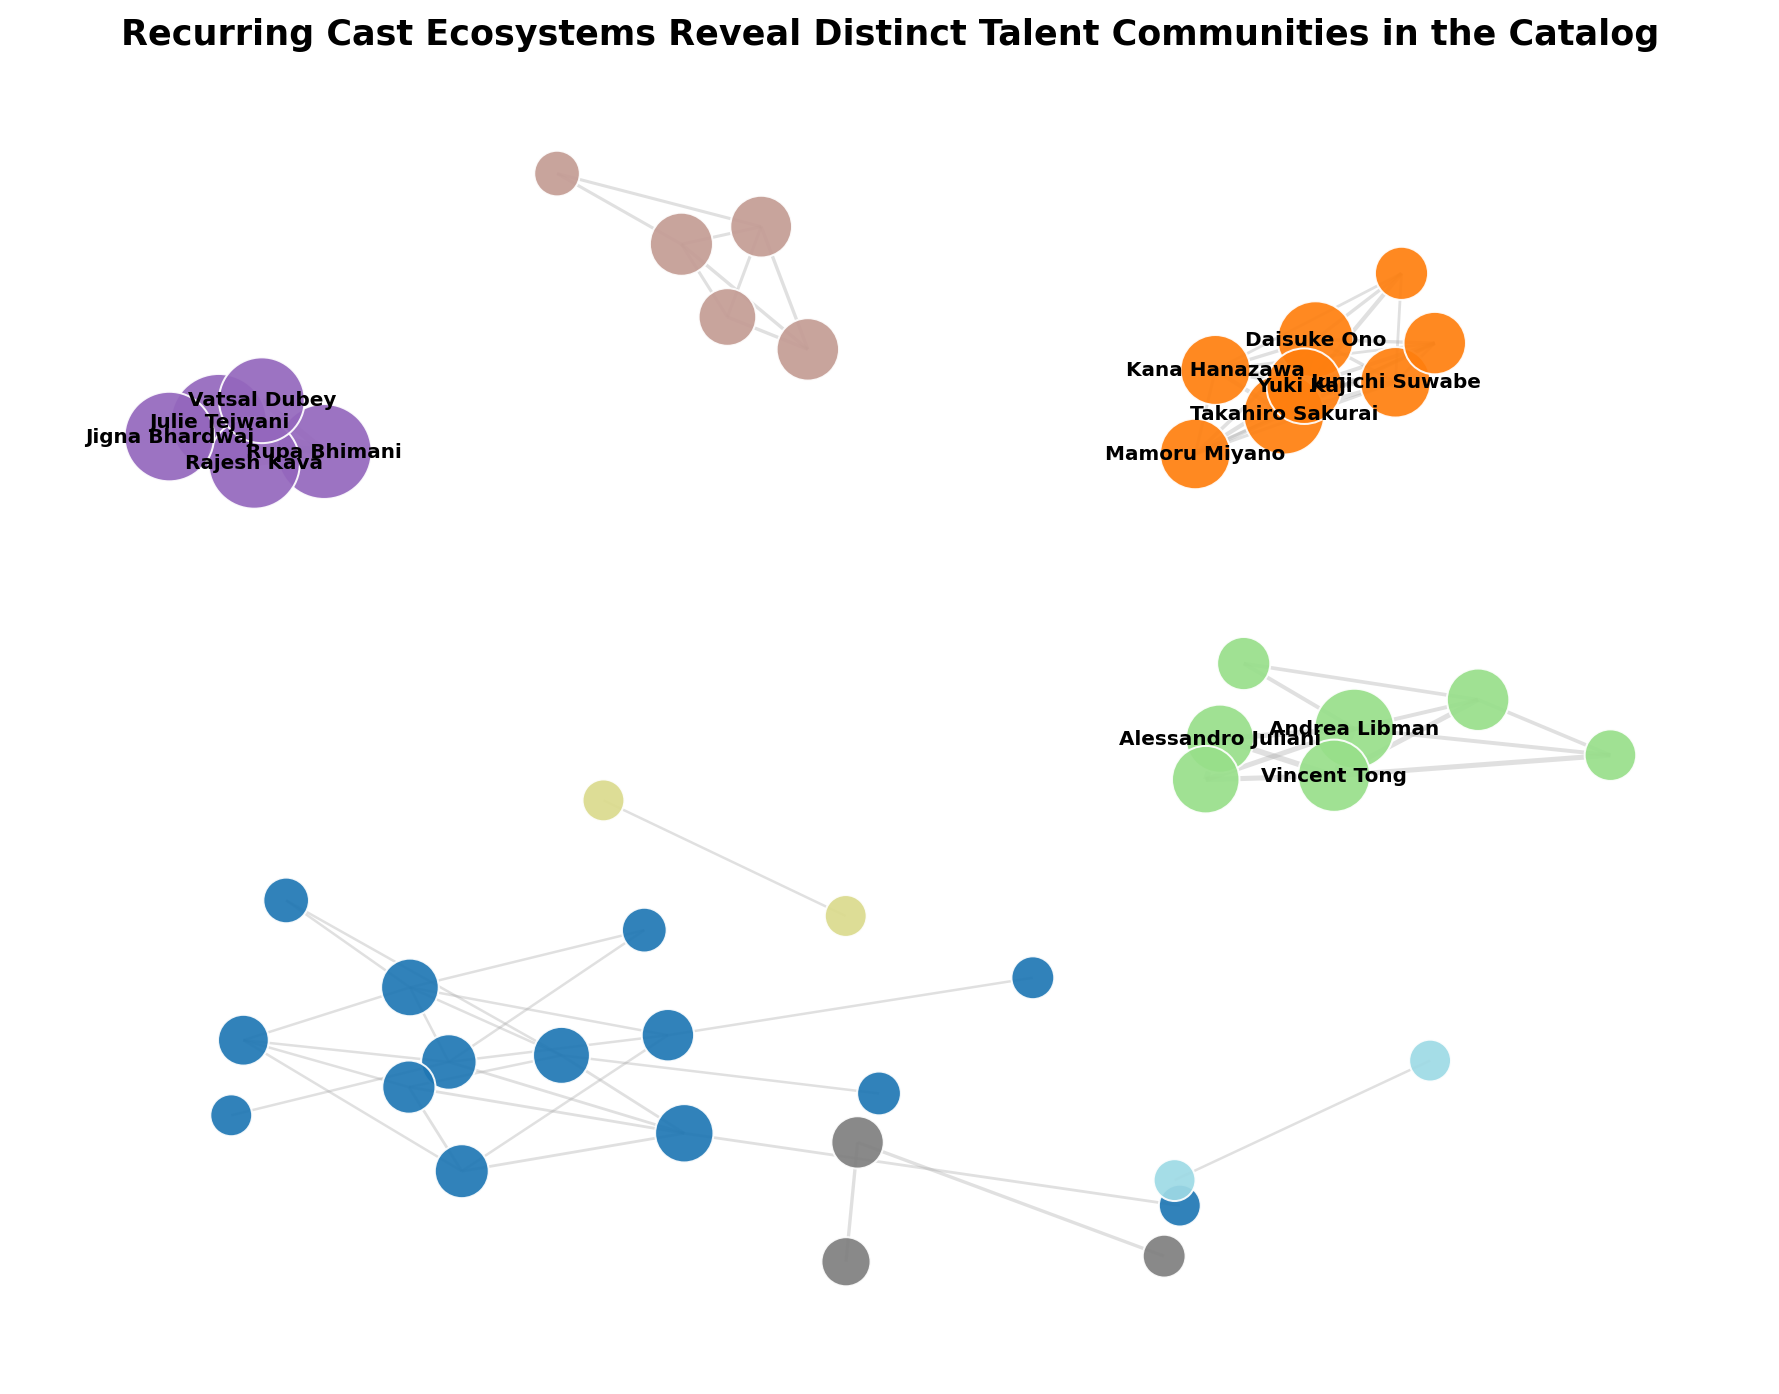

In [12]:

display(repeated_directors)
display(repeated_cast)
display(director_cast_collaborations)
display(cast_community_summary)
display(cast_ecosystem_hubs.head(15))
show_figure('phase3_08_cast_ecosystem_network.png', width=1200)



**Observation**

- Repeat director presence is concentrated among format specialists and a smaller set of high-breadth film directors.
- Repeat cast presence is even more revealing: catalog recurrence clusters around recognizable talent ecosystems rather than a flat pool of isolated actors.

**Interpretation**

- The people layer suggests that catalog supply is partly organized around reusable production ecosystems, not only around individual titles.
- That is especially visible in stand-up specials, Indian film ensembles, and animation or anime voice communities.

**Business relevance**

- This adds a commercially relevant dimension to the project because it shows where Netflix's library metadata implies ecosystem concentration and repeatable sourcing patterns.
- It also demonstrates judgment: the people analysis stays connected to portfolio structure instead of drifting into decorative network science.



**Observation**

- The cast co-appearance graph resolves into a handful of distinct communities instead of one diffuse web.
- Several hubs represent coherent catalog ecosystems, including Indian film ensembles, Western animation voice talent, anime voice talent, and a classic comedy cluster.

**Interpretation**

- The network is most useful when read as an ecosystem map: repeated communities likely reflect consistent sourcing lanes or catalog niches rather than one-off coincidences.
- Community structure strengthens the broader Phase 3 story that the catalog is organized through a mix of global scale buckets and specialized creative sub-ecosystems.

**Business relevance**

- This is a strong portfolio chart because it turns normalized people metadata into a clear strategic narrative without overstating what the dataset can prove.
- It is also selective enough to keep credibility: one well-justified network chart is much stronger than a large appendix of graph statistics.



## Phase 3 Takeaways

Phase 3 adds depth in three ways:

- it converts static catalog shares into a time-evolution story
- it compresses the library into a small set of labeled strategic segments
- it surfaces recurring talent ecosystems that help explain how parts of the catalog are assembled

For final portfolio packaging, the strongest Phase 3 assets are the titles-added profile, geographic diversification over time, the two cluster visuals, and the cast ecosystem network. The weakest outputs are the full director-cast collaboration table and any overly detailed node-level network exports; those are useful for auditability but should stay in the appendix rather than the front page.
